# Imports

In [93]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Loading

In [94]:
# Set the data working directory
print(os.getcwd())
DATA_PATH = "/Users/teo/Library/CloudStorage/GoogleDrive-t.leprovost@student.uw.edu.pl/My Drive/Studies_UW/Warsaw_Econometrics_Challenge"
os.chdir(DATA_PATH)

/Users/teo/Library/CloudStorage/GoogleDrive-t.leprovost@student.uw.edu.pl/My Drive/Studies_UW/Warsaw_Econometrics_Challenge


In [95]:
# Load each dataset
behaviour  = pd.read_csv('data/player_appearance_behaviour_under_pressure.csv')
passes     = pd.read_csv('data/player_appearance_pass.csv')
runs       = pd.read_csv('data/player_appearance_run.csv')
shots      = pd.read_csv('data/player_appearance_shot_limited.csv')
quarters   = pd.read_csv('data/players_quarters_final.csv')

# Quick check
for name, df in [('behaviour', behaviour), ('passes', passes),
                 ('runs', runs), ('shots', shots), ('quarters', quarters)]:
    print(f"{name}: {df.shape}")

behaviour: (12185, 10)
passes: (29795, 7)
runs: (35133, 10)
shots: (780, 12)
quarters: (3486, 33)


In [96]:
# Set options to prevent truncation of columns in dataframe displays
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

# Data cleaning

## Missing Values

In [97]:
quarters.columns[quarters.isnull().any()]


Index([], dtype='object')

In [98]:
quarters.isnull().sum()

player_appearance_id        0
player_id                   0
fixture_id                  0
date                        0
checkpoint                  0
checkpoint_period           0
checkpoint_min              0
position                    0
is_home                     0
formation                   0
minute_in                   0
minute_out                  0
subbed                      0
jersey_number               0
last15_sprints              0
last15_hsr                  0
last15_distance             0
last15_mean_max_speed       0
last15_peak_speed           0
last15_shots                0
last15_shots_on_target      0
last15_shots_under_press    0
last15_shots_top_third      0
cumul_sprints               0
cumul_hsr                   0
cumul_distance              0
cumul_mean_max_speed        0
cumul_peak_speed            0
cumul_shots                 0
cumul_shots_on_target       0
cumul_shots_under_press     0
cumul_shots_top_third       0
scored_after                0
dtype: int

No missing data ✅

In [99]:
# Check duplicates
quarters.duplicated().sum()

np.int64(0)

In [100]:
# Single player checkpoint duplicates: a player should only appear only once per match checkpoint
key = ['player_id', 'fixture_id', 'checkpoint']
print(f"Specific duplicates: {quarters.duplicated(subset=key).sum()}")
# quarters[quarters.duplicated(subset=key, keep=False)].sort_values(key)

Specific duplicates: 0


No duplicates ✅

# Data description

In [101]:
quarters.head()

,player_appearance_id,player_id,fixture_id,date,checkpoint,checkpoint_period,checkpoint_min,position,is_home,formation,minute_in,minute_out,subbed,jersey_number,last15_sprints,last15_hsr,last15_distance,last15_mean_max_speed,last15_peak_speed,last15_shots,last15_shots_on_target,last15_shots_under_press,last15_shots_top_third,cumul_sprints,cumul_hsr,cumul_distance,cumul_mean_max_speed,cumul_peak_speed,cumul_shots,cumul_shots_on_target,cumul_shots_under_press,cumul_shots_top_third,scored_after
0,39421,2702,1159,2025-06-11,H1_15,half_1,15,G,True,4-1-4-1,1,90,False,1,0,0,0.00,0.000,0.00,0,0,0,0,0,0,0.00,0.000,0.00,0,0,0,0,0
1,39422,2732,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,2,2,5,68.15,6.806,7.46,0,0,0,0,2,5,68.15,6.806,7.46,0,0,0,0,0
2,39423,3296,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,4,2,4,68.49,7.165,7.87,0,0,0,0,2,4,68.49,7.165,7.87,0,0,0,0,0
3,39424,3297,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,5,1,5,80.36,6.873,8.95,0,0,0,0,1,5,80.36,6.873,8.95,0,0,0,0,0
4,39425,3298,1159,2025-06-11,H1_15,half_1,15,A,True,4-1-4-1,1,75,True,6,4,15,183.30,6.533,7.68,0,0,0,0,4,15,183.30,6.533,7.68,0,0,0,0,0


In [102]:
quarters.tail()

,player_appearance_id,player_id,fixture_id,date,checkpoint,checkpoint_period,checkpoint_min,position,is_home,formation,minute_in,minute_out,subbed,jersey_number,last15_sprints,last15_hsr,last15_distance,last15_mean_max_speed,last15_peak_speed,last15_shots,last15_shots_on_target,last15_shots_under_press,last15_shots_top_third,cumul_sprints,cumul_hsr,cumul_distance,cumul_mean_max_speed,cumul_peak_speed,cumul_shots,cumul_shots_on_target,cumul_shots_under_press,cumul_shots_top_third,scored_after
3481,43996,3579,1237,2025-06-21,H2_30,half_2,30,D,False,4-4-2,1,90,False,16,1,9,112.81,6.527,8.23,0,0,0,0,4,36,536.66,6.389,8.61,0,0,0,0,0
3482,43997,3563,1237,2025-06-21,H2_30,half_2,30,A,False,4-4-2,1,81,True,18,6,10,194.24,7.103,8.21,0,0,0,0,21,56,939.81,6.872,8.83,1,0,1,1,0
3483,44001,3566,1237,2025-06-21,H2_30,half_2,30,M,False,4-4-2,1,90,False,23,3,9,135.74,6.617,8.21,1,0,1,0,10,47,729.21,6.598,8.21,1,0,1,0,0
3484,44003,3314,1237,2025-06-21,H2_30,half_2,30,M,True,4-1-4-1,71,90,False,10,0,3,35.75,6.320,6.87,0,0,0,0,0,3,35.75,6.320,6.87,0,0,0,0,0
3485,44010,3558,1237,2025-06-21,H2_30,half_2,30,M,False,4-4-2,71,90,False,6,1,5,60.38,6.632,7.41,0,0,0,0,1,5,60.38,6.632,7.41,0,0,0,0,0


In [103]:
# Check data types
summary = pd.DataFrame({
    'Type': quarters.dtypes,
    'Non-Null': quarters.count(),
    'Nulls': quarters.isnull().sum(),
    'Unique': quarters.nunique()
})

summary

,Type,Non-Null,Nulls,Unique
player_appearance_id,int64,3486,0,869
player_id,int64,3486,0,307
fixture_id,int64,3486,0,31
date,object,3486,0,10
checkpoint,object,3486,0,7
checkpoint_period,object,3486,0,3
checkpoint_min,int64,3486,0,3
position,object,3486,0,4
is_home,bool,3486,0,2
formation,object,3486,0,10


In [104]:
for col in quarters.columns:
    print(quarters[col].value_counts(dropna=False).sort_index(ascending=True))
    print("\n")

player_appearance_id
39421    5
39422    5
39423    5
39424    5
39425    5
        ..
65785    5
65786    3
65787    5
65788    5
65789    2
Name: count, Length: 869, dtype: int64


player_id
400     15
445      7
455      7
527      5
761      4
        ..
3575     1
3576     7
3578     1
3579    23
3582     8
Name: count, Length: 307, dtype: int64


fixture_id
1159    110
1160    110
1161    110
1162    110
1163    110
1164    110
1165    110
1166    110
1167    110
1169    110
1170    110
1171    110
1188    105
1189    110
1190    110
1191    110
1198    110
1200    110
1201    110
1202    110
1204    110
1205    110
1206    110
1207    110
1215    106
1216    110
1219    110
1220    110
1221    151
1225    154
1237    110
Name: count, dtype: int64


date
2025-06-11    440
2025-06-12    440
2025-06-14    440
2025-06-15    440
2025-06-17    435
2025-06-18    440
2025-06-21    326
2025-06-22    151
2025-06-25    220
2025-06-28    154
Name: count, dtype: int64


checkpoint
ET1_15    

In [105]:
# Transform id features as character string
quarters['player_appearance_id'] = quarters['player_appearance_id'].astype(str)
quarters['player_id'] = quarters['player_id'].astype(str)
quarters['fixture_id'] = quarters['fixture_id'].astype(str)

# date : object → datetime
quarters['date'] = pd.to_datetime(quarters['date'])

In [106]:
print(quarters[['checkpoint_period', 'checkpoint_min']].drop_duplicates().sort_values(['checkpoint_period', 'checkpoint_min']))

     checkpoint_period  checkpoint_min
3202      extra_time_1              15
0               half_1              15
22              half_1              30
44              half_1              45
66              half_2              15
88              half_2              30
3181            half_2              45


# Data Visualization

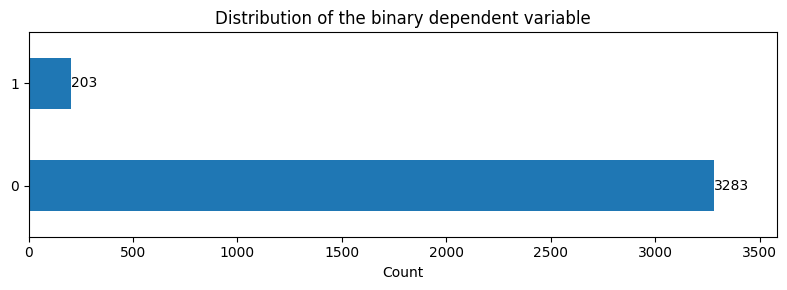

In [107]:
# Plot distribution of scored_after
# And remove the name "scored_after" on the y axis
quarters['scored_after'].value_counts().plot(kind='barh', figsize=(8, 3))  # figsize controls the plot size

plt.xlabel('Count')
plt.title('Distribution of the binary dependent variable')
plt.ylabel('')  # Remove the label from the y-axis

for index, value in enumerate(quarters['scored_after'].value_counts()):
    plt.text(value, index, str(value), ha='left', va='center', fontsize=10)

plt.xlim(0, max(quarters['scored_after'].value_counts()) + 300)
plt.tight_layout()
plt.show()

In [108]:
# Histograms for numerical variables
# quarters.hist(figsize=(15, 10), bins=30)
# plt.tight_layout()
# plt.show()

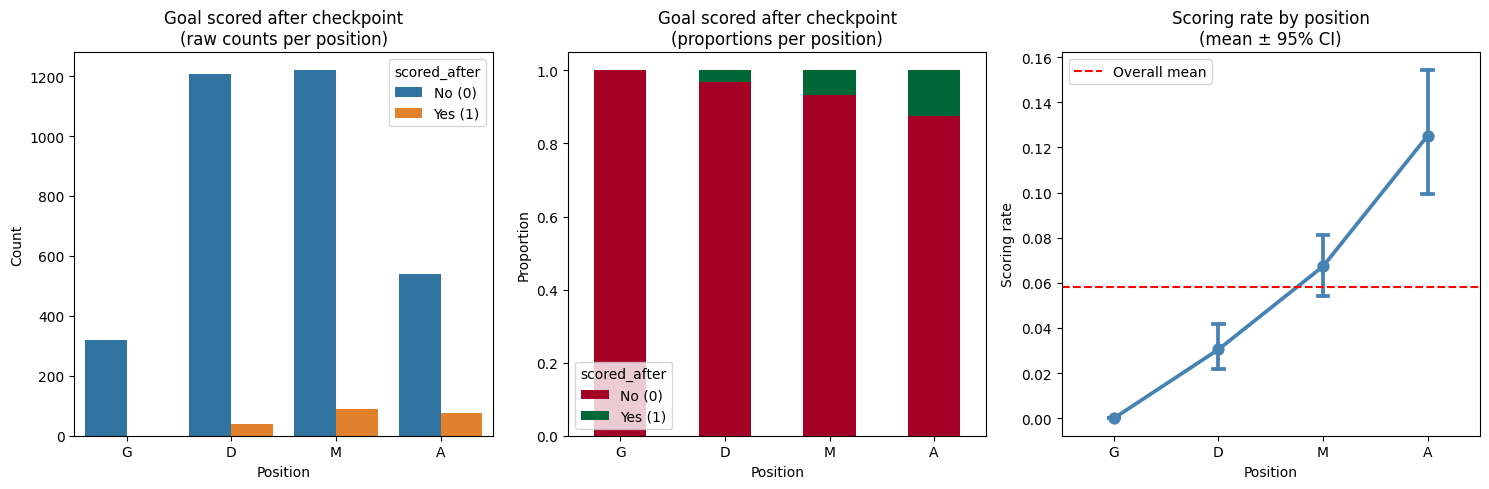

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

position_order = ['G', 'D', 'M', 'A']

# --- Plot 1: Count plot (raw counts) ---
sns.countplot(data=quarters, x='position', hue='scored_after', ax=axes[0], order=position_order)
axes[0].set_title('Goal scored after checkpoint\n(raw counts per position)')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Count')
axes[0].legend(title='scored_after', labels=['No (0)', 'Yes (1)'])

# --- Plot 2: Stacked bar (proportions per position) ---
prop = quarters.groupby('position')['scored_after'].value_counts(normalize=True).unstack()
prop = prop.reindex(position_order)  # Reorder rows
prop.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Goal scored after checkpoint\n(proportions per position)')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='scored_after', labels=['No (0)', 'Yes (1)'], loc='lower left')
axes[1].tick_params(axis='x', rotation=0)

# --- Plot 3: Scoring rate as a point plot with confidence interval ---
sns.pointplot(data=quarters, x='position', y='scored_after', ax=axes[2],
              capsize=0.1, color='steelblue', order=position_order)
axes[2].set_title('Scoring rate by position\n(mean ± 95% CI)')
axes[2].set_xlabel('Position')
axes[2].set_ylabel('Scoring rate')
axes[2].axhline(quarters['scored_after'].mean(), color='red', linestyle='--', label='Overall mean')
axes[2].legend()

plt.tight_layout()
plt.show()

# Data Filtering

In [110]:
# Identify the end time of each match (in minutes) by taking the maximum minute_out for each fixture_id

fixtures = quarters.groupby('fixture_id')
fixture_end_time = fixtures['minute_out'].max().reset_index()
players_per_fixture = fixtures['player_id'].nunique().reset_index()

players_per_fixture.columns = ['fixture_id', 'num_players']
print(players_per_fixture)

   fixture_id  num_players
0        1159           26
1        1160           28
2        1161           27
3        1162           26
4        1163           28
5        1164           28
6        1165           27
7        1166           25
8        1167           31
9        1169           27
10       1170           29
11       1171           29
12       1188           27
13       1189           28
14       1190           30
15       1191           29
16       1198           29
17       1200           28
18       1201           28
19       1202           30
20       1204           29
21       1205           28
22       1206           27
23       1207           27
24       1215           25
25       1216           26
26       1219           28
27       1220           24
28       1221           33
29       1225           32
30       1237           30


In [111]:
fixture_end_time.columns = ['fixture_id', 'match_end_minute']
print(fixture_end_time)

   fixture_id  match_end_minute
0        1159                90
1        1160                90
2        1161                90
3        1162                90
4        1163                90
5        1164                90
6        1165                90
7        1166                90
8        1167                90
9        1169                90
10       1170                90
11       1171                90
12       1188                90
13       1189                90
14       1190                90
15       1191                90
16       1198                90
17       1200                90
18       1201                90
19       1202                90
20       1204                90
21       1205                90
22       1206                90
23       1207                90
24       1215                90
25       1216                90
26       1219                90
27       1220                90
28       1221               120
29       1225               120
30      

We decide to remove the extra time quarters for data structure convenience, because there is only two matches that went in extra time, but there is no `extra_time_2` values in `checkpoint_period` variable, and no `ET1_15` value in `checkpoint` variable. Which means that if we want to properly analyze any data that happened in those quarters, we need to infer all of them from the additional data, which would be time consuming

We will therefore analyze all the games until the 90th minutes, even for the games 1221 and 1225 that went on extra time.

Row filtering:
- Remove the position goalkeeper for the training?
- Remove the rows for extra time 1, for structure convenience
- Remove all the lines where the player was not on the pitch the full quarter?
- Remove the jersey number as it is relevant to be used only as an identifier

In [112]:
# Remove rows for extra time 1 (not enough data, only 1.5% of rows)
print(f"Shape before filtering  : {quarters.shape}")
quarters = quarters[quarters['checkpoint_period'] != 'extra_time_1']
print(f"Shape after filtering extra_time_1: {quarters.shape}")

# Remove goalkeepers: they almost never score and have
# fundamentally different physical profiles
quarters = quarters[quarters["position"] != 'G']
print(f"Shape after removing goalkeepers: {quarters.shape}")

# Remove rows where last15_peak_speed == 0:
# these are players not yet fully on the pitch at the checkpoint
quarters = quarters[quarters["last15_peak_speed"] != 0.0]
print(f"Shape after removing zero-speed rows: {quarters.shape}")

# # Drop jersey_number: not informative for modeling
# quarters = quarters.drop(columns=["jersey_number"])

Shape before filtering  : (3486, 33)
Shape after filtering extra_time_1: (3444, 33)
Shape after removing goalkeepers: (3130, 33)
Shape after removing zero-speed rows: (3114, 33)


For the model:
- Transform checkpoint_min so it goes until 90 min, not only 45 min

In [113]:
quarters.loc[(quarters['checkpoint_period'] == 'half_2') & (quarters['checkpoint_min'] <= 45), 'checkpoint_min'] = \
    quarters.loc[(quarters['checkpoint_period'] == 'half_2') & (quarters['checkpoint_min'] <= 45), 'checkpoint_min'] + 45

In [114]:
#rename chekpoint values H2_15 to H2_60, H2_30 to H2-75 and H2_45 to H2_90
quarters.loc[quarters['checkpoint'] == 'H2_15', 'checkpoint'] = 'H2_60'
quarters.loc[quarters['checkpoint'] == 'H2_30', 'checkpoint'] = 'H2_75'
quarters.loc[quarters['checkpoint'] == 'H2_45', 'checkpoint'] = 'H2_90'

# Verify
print(quarters[['checkpoint', 'checkpoint_min']].drop_duplicates().sort_values(['checkpoint', 'checkpoint_min']))

     checkpoint  checkpoint_min
1         H1_15              15
23        H1_30              30
45        H1_45              45
67        H2_60              60
89        H2_75              75
3182      H2_90              90


# Feature engineering

In [115]:
# Passing data
passes = pd.read_csv("data/with_fixture_id/player_appearance_pass.csv")

# From the player_appearance_pass.csv dataset, we need to count for each appearance_id the number of the ids of passes that are in the value of stage value "top"
passes_top = passes[passes['stage'] == 'top']
passes_top_count = passes_top.groupby('player_appearance_id').size().reset_index(name='passes_top_count')
passes_top_count.head(10)

,player_appearance_id,passes_top_count
0,39422,3
1,39423,3
2,39424,11
3,39425,3
4,39426,5
5,39427,2
6,39428,2
7,39429,2
8,39430,1
9,39431,4


In [116]:
# Aggregate that data to the quarters dataset, by merging on player_appearance_id. We will have a new column in quarters with the number of passes in the top stage for each player appearance.
# called last15_passes_top_third
# Fill with 0s instead of NaN for the count, since if there are no passes in the top third, the count should be 0, not NaN
passes_top_count['player_appearance_id'] = passes_top_count['player_appearance_id'].astype(int)
quarters['player_appearance_id'] = quarters['player_appearance_id'].astype(int)

quarters = quarters.merge(passes_top_count, on='player_appearance_id', how='left')
quarters['last15_passes_top_third'] = quarters['passes_top_count']
quarters.drop(columns=['passes_top_count'], inplace=True)
quarters['last15_passes_top_third'].value_counts(dropna=False).sort_index(ascending=True)

last15_passes_top_third
1.0     238
2.0     276
3.0     195
4.0     231
5.0     193
6.0     257
7.0     157
8.0     148
9.0     112
10.0    100
11.0    113
12.0     96
13.0    115
14.0     83
15.0     63
16.0     58
17.0     35
18.0     25
19.0     40
20.0     16
21.0     52
22.0     39
23.0     32
24.0     20
25.0     15
26.0     29
27.0     14
28.0      8
29.0     29
30.0     21
31.0     20
32.0     12
33.0     10
34.0      6
35.0      5
39.0      9
40.0      5
42.0      5
45.0      5
48.0      5
55.0      5
NaN     217
Name: count, dtype: int64

In [117]:
quarters.head()

,player_appearance_id,player_id,fixture_id,date,checkpoint,checkpoint_period,checkpoint_min,position,is_home,formation,minute_in,minute_out,subbed,jersey_number,last15_sprints,last15_hsr,last15_distance,last15_mean_max_speed,last15_peak_speed,last15_shots,last15_shots_on_target,last15_shots_under_press,last15_shots_top_third,cumul_sprints,cumul_hsr,cumul_distance,cumul_mean_max_speed,cumul_peak_speed,cumul_shots,cumul_shots_on_target,cumul_shots_under_press,cumul_shots_top_third,scored_after,last15_passes_top_third
0,39422,2732,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,2,2,5,68.15,6.806,7.46,0,0,0,0,2,5,68.15,6.806,7.46,0,0,0,0,0,3.0
1,39423,3296,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,4,2,4,68.49,7.165,7.87,0,0,0,0,2,4,68.49,7.165,7.87,0,0,0,0,0,3.0
2,39424,3297,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,5,1,5,80.36,6.873,8.95,0,0,0,0,1,5,80.36,6.873,8.95,0,0,0,0,0,11.0
3,39425,3298,1159,2025-06-11,H1_15,half_1,15,A,True,4-1-4-1,1,75,True,6,4,15,183.30,6.533,7.68,0,0,0,0,4,15,183.30,6.533,7.68,0,0,0,0,0,3.0
4,39426,3299,1159,2025-06-11,H1_15,half_1,15,M,True,4-1-4-1,1,87,True,7,4,9,138.44,6.866,8.45,0,0,0,0,4,9,138.44,6.866,8.45,0,0,0,0,1,5.0


In [118]:
# Calculate the cumulative sum of passes_top_count for each player_appearance_id, ordered by checkpoint_min, and store it in a new column called cumul_passes_top_third
# Fill with 0s instead of NaN for the cumulative sum, since if there are no passes in the top third, the cumulative sum should be 0, not NaN
if 'last15_passes_top_third' in quarters.columns:
    quarters['cumul_passes_top_third'] = quarters.groupby('player_appearance_id')['last15_passes_top_third'].cumsum()
else:
    print("Colonne 'last15_passes_top_third' introuvable")
    print("Colonnes disponibles:", quarters.columns.tolist())
quarters['cumul_passes_top_third'] = quarters.groupby('player_appearance_id')['last15_passes_top_third'].cumsum()
quarters['cumul_passes_top_third'].value_counts(dropna=False).sort_index(ascending=True)
quarters.head(200)

,player_appearance_id,player_id,fixture_id,date,checkpoint,checkpoint_period,checkpoint_min,position,is_home,formation,minute_in,minute_out,subbed,jersey_number,last15_sprints,last15_hsr,last15_distance,last15_mean_max_speed,last15_peak_speed,last15_shots,last15_shots_on_target,last15_shots_under_press,last15_shots_top_third,cumul_sprints,cumul_hsr,cumul_distance,cumul_mean_max_speed,cumul_peak_speed,cumul_shots,cumul_shots_on_target,cumul_shots_under_press,cumul_shots_top_third,scored_after,last15_passes_top_third,cumul_passes_top_third
0,39422,2732,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,2,2,5,68.15,6.806,7.46,0,0,0,0,2,5,68.15,6.806,7.46,0,0,0,0,0,3.0,3.0
1,39423,3296,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,4,2,4,68.49,7.165,7.87,0,0,0,0,2,4,68.49,7.165,7.87,0,0,0,0,0,3.0,3.0
2,39424,3297,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,5,1,5,80.36,6.873,8.95,0,0,0,0,1,5,80.36,6.873,8.95,0,0,0,0,0,11.0,11.0
3,39425,3298,1159,2025-06-11,H1_15,half_1,15,A,True,4-1-4-1,1,75,True,6,4,15,183.30,6.533,7.68,0,0,0,0,4,15,183.30,6.533,7.68,0,0,0,0,0,3.0,3.0
4,39426,3299,1159,2025-06-11,H1_15,half_1,15,M,True,4-1-4-1,1,87,True,7,4,9,138.44,6.866,8.45,0,0,0,0,4,9,138.44,6.866,8.45,0,0,0,0,1,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,39490,3345,1160,2025-06-11,H2_75,half_2,75,A,False,4-3-3,46,90,False,10,2,9,98.92,6.496,7.74,0,0,0,0,4,15,189.51,6.528,7.78,0,0,0,0,0,9.0,18.0
196,39491,3346,1160,2025-06-11,H2_75,half_2,75,D,False,4-3-3,1,90,False,11,0,3,27.02,6.143,6.47,0,0,0,0,5,33,449.88,6.455,8.15,0,0,0,0,0,22.0,110.0
197,39495,3350,1160,2025-06-11,H2_75,half_2,75,A,False,4-3-3,61,90,False,18,3,7,135.44,6.804,7.89,0,0,0,0,3,7,135.44,6.804,7.89,0,0,0,0,0,1.0,1.0
198,39496,3351,1160,2025-06-11,H2_75,half_2,75,A,False,4-3-3,1,90,False,19,0,8,101.87,6.239,7.22,0,0,0,0,8,39,581.23,6.684,8.77,0,0,0,0,0,28.0,140.0


Feature engineering:
- Increase of each measurement  = measurement on last 15 min / (total cumul / ((checkpoint_min - minute_in+1)/15)) > 1

In [119]:
# ── Ratio variables: last 15 min vs average 15-min window over the rest of the match ──
# Formula: last15_x / (cumul_x / (active_windows))
# where active_windows = number of 15-min windows the player has been on pitch so far

# Time the player has been active at checkpoint (in minutes)
quarters["minutes_active"] = quarters["checkpoint_min"] - quarters["minute_in"] + 1

# Number of complete 15-min windows covered so far (the "rest of the match")
quarters["active_windows"] = quarters["minutes_active"] / 15

# if quarters['checkpoint'] is 'H1_15':
#     quarters["active_windows"] = 1
# elif quarters['checkpoint'] is 'H1_30':
#     quarters["active_windows"] = 2
# elif quarters['checkpoint'] is 'H1_45':
#     quarters["active_windows"] = 3
# elif quarters['checkpoint'] is 'H2_15':
#     quarters["active_windows"] = 4
# elif quarters['checkpoint'] is 'H2_30':
#     quarters["active_windows"] = 5
# elif quarters['checkpoint'] is 'H2_45':
#     quarters["active_windows"] = 6      

# Pairs: (last15_col, cumul_col)
ratio_pairs = [
    ("last15_sprints",            "cumul_sprints"),
    ("last15_hsr",                "cumul_hsr"),
    ("last15_distance",           "cumul_distance"),
    ("last15_mean_max_speed",     "cumul_mean_max_speed"),
    ("last15_peak_speed",         "cumul_peak_speed"),
    ("last15_shots",              "cumul_shots"),
    ("last15_shots_on_target",    "cumul_shots_on_target"),
    ("last15_shots_under_press",  "cumul_shots_under_press"),
    ("last15_shots_top_third",    "cumul_shots_top_third"),
    ("last15_passes_top_third",   "cumul_passes_top_third")
]

for last15_col, cumul_col in ratio_pairs:
    ratio_col = last15_col.replace("last15_", "ratio_")

    # Average 15-min activity over the whole match so far
    avg_per_window = quarters[cumul_col] / quarters["active_windows"]

    # Ratio > 1 → player is MORE active in last 15 min than their match average
    # Ratio < 1 → player is LESS active in last 15 min than their match average
    # NaN      → avg is 0 (no activity recorded at all → ratio undefined)
    quarters[ratio_col] = quarters[last15_col] / avg_per_window  # Avoid division by zero; set ratio to NaN when avg_per_window is 0

    print(quarters[ratio_col].value_counts(dropna=False).sort_index(ascending=True))

print(quarters['minutes_active'].value_counts(dropna=False).sort_index(ascending=True))
print(quarters['active_windows'].value_counts(dropna=False).sort_index(ascending=True))

ratio_sprints
0.000000    501
0.133333      5
0.200000      3
0.222222      1
0.235294      1
           ... 
3.200000      1
3.333333      1
4.000000      6
5.000000      1
NaN         207
Name: count, Length: 127, dtype: int64
ratio_hsr
0.000000     3
0.133333    11
0.176471     1
0.178571     4
0.181818     3
            ..
2.250000     1
2.291667     1
2.307692     1
2.333333     1
NaN          1
Name: count, Length: 470, dtype: int64
ratio_distance
0.053177    1
0.069163    1
0.075347    1
0.085677    1
0.086106    1
           ..
2.317490    1
2.415565    1
2.416025    1
2.417963    1
2.436172    1
Name: count, Length: 2347, dtype: int64
ratio_mean_max_speed
0.133333    11
0.200000     2
0.200000     5
0.200000     4
0.266667    15
            ..
6.406735     1
6.478921     1
6.605064     1
7.134199     1
7.299485     1
Name: count, Length: 2342, dtype: int64
ratio_peak_speed
0.133333    11
0.200000     3
0.200000     6
0.200000     2
0.266667    15
            ..
5.914692     1


# Offensiveness formation

In [120]:
quarters['formation'].unique()

array(['4-1-4-1', '4-4-2', '4-3-3', '5-4-1', '4-2-3-1', '3-4-3',
       '4-1-3-2', '5-2-3', '4-2-4', '3-4-2-1'], dtype=object)

- Create a new formation_offensiveness variable to avoir heavy encoding on formation data

In [121]:
# Create a new formation_offensiveness variable to avoid heavy encoding on formation data
# Calculate a score mutliplying X defender times 1 + Y midfielder times 2 + Z attacker times 3. If a fomartion is 4 layers, layers 2 and 3 are both midlfielders.
def calculate_offensiveness(formation):
    # On sépare les chiffres (ex: "4-2-3-1" -> ["4", "2", "3", "1"])
    parts = [int(x) for x in str(formation).split('-')]
    
    if len(parts) == 3:
        # Cas classique : 4-4-2, 4-3-3
        defenders, midfielders, attackers = parts
        return (defenders * 1) + (midfielders * 2) + (attackers * 3)
    
    elif len(parts) == 4:
        # Cas à 4 lignes : 4-2-3-1, 4-1-4-1
        # Les deux chiffres du milieu sont combinés pour le milieu de terrain
        defenders, mid1, mid2, attackers = parts
        midfielders = mid1 + mid2
        return (defenders * 1) + (midfielders * 2) + (attackers * 3)
    
    return None

# Application sur le DataFrame
quarters['formation_offensiveness'] = quarters['formation'].apply(calculate_offensiveness)
quarters['formation_offensiveness'].value_counts(dropna=False).sort_index(ascending=True)

formation_offensiveness
16     100
17    1293
18     625
19     748
20     348
Name: count, dtype: int64

In [122]:
# Save the data in a new csv file
quarters.to_csv('players_quarters_final_cleaned.csv', index=False)

In [123]:
# Sort by player_id first, then by fixture_id, then by checkpoint
# quarters_sorted = quarters.sort_values(by=['player_id', 'fixture_id', 'checkpoint']).reset_index(drop=True)

# Shots accuracy

In [124]:
# Shot quality ratio: proportion of shots on target (cumulative and last 15 min)
quarters['cumul_shot_accuracy'] = quarters['cumul_shots_on_target'] / (quarters['cumul_shots'] + 1e-6)
quarters['last15_shot_accuracy'] = quarters['last15_shots_on_target'] / (quarters['last15_shots'] + 1e-6)

# Minutes remaining in match

In [125]:
# minute_out is already counted continuously from match start
quarters['minutes_remaining'] = quarters['minute_out'] - quarters['checkpoint_min']
quarters['minutes_remaining'].value_counts(dropna=False).sort_index(ascending=True)

minutes_remaining
0      12
1      44
2      16
3      13
4      22
       ..
87      2
90     15
91      1
99      1
105    15
Name: count, Length: 85, dtype: int64

In [126]:
# call the describe function for the following variables: date, checkpoint, position, is_home, formation, formation_ofensiveness, minute_in, minute_out, last15_sprints, last_shots, last15_passes_top_third, cumul_sprints, cumul_shots, cumul_passes_top_third, scored_after
col_describe = ['checkpoint', 'position', 'is_home', 'formation', 'formation_offensiveness', 'minute_in', 'minute_out', 'ratio_sprints', 'ratio_shots', 'ratio_passes_top_third', 'scored_after']

quarters[col_describe].describe().round(2)

,formation_offensiveness,minute_in,minute_out,ratio_sprints,ratio_shots,ratio_passes_top_third,scored_after
count,3114.00,3114.00,3114.00,2907.00,993.00,2897.00,3114.00
mean,17.98,5.47,84.36,0.94,1.12,0.98,0.06
std,1.11,15.70,13.67,0.64,1.42,0.11,0.25
min,16.00,1.00,21.00,0.00,0.00,0.13,0.00
25%,17.00,1.00,80.00,0.56,0.00,1.00,0.00
50%,18.00,1.00,90.00,1.00,0.47,1.00,0.00
75%,19.00,1.00,90.00,1.25,2.00,1.00,0.00
max,20.00,87.00,120.00,5.00,6.00,1.50,1.00


# Merge this feature engineering with auto-EDA dataset

In [127]:
# Merge the current manual EDA with the exhaustive auto-EDA
quarters_1 = pd.read_csv("EDA2/features/all_engineered_features.csv")
quarters_2 = pd.read_csv("data/players_quarters_final_feature_engineered_v3.csv")

print(quarters_1.shape)
print(quarters_2.shape)

(3486, 74)
(3114, 51)


In [128]:
quarters = pd.concat([quarters_1, quarters_2], axis=1, join="outer")
print(quarters.shape)

# Get the index of rows that are in quarters_1 but not in quarters_2
index_diff = quarters_1.index.difference(quarters_2.index)

# Remove rows not present in both datasets
quarters = quarters.drop(index=index_diff)
print(quarters.shape)

# --- FIX: Remove duplicate columns created by the concat ---
quarters = quarters.loc[:, ~quarters.columns.duplicated()]
print(f"Shape after deduplication: {quarters.shape}")

quarters.head(10)

quarters.to_csv('data/all_data.csv', index=False)

(3486, 125)
(3114, 125)
Shape after deduplication: (3114, 123)


In [129]:
quarters = pd.read_csv('data/all_data.csv')

# Player behavior features: last15_ and cumul_ features
last15_features = [last15_col for last15_col in quarters.columns if last15_col.startswith("last15_")]
cumul_features = [cumul_col for cumul_col in quarters.columns if cumul_col.startswith("cumul_")]

player_behavior_features = last15_features + cumul_features

# Team level features
team_level_features = ['position', 'is_home', 'formation', 'minute_in', 'minute_out', 'subbed']

In [130]:
# Numerical features only (last15_ and cumul_)
numeric_features = player_behavior_features + ['checkpoint_min', 'scored_after']

# Compute Pearson correlation matrix
correlations = quarters[numeric_features].corr(method='pearson')

# Sort all features by their correlation with scored_after (descending)
correlation_with_target = correlations['scored_after'].sort_values(ascending=False)
ordered_columns = correlation_with_target.index

# Reorder the matrix
correlations = correlations[ordered_columns].loc[ordered_columns]

print(correlation_with_target)

scored_after                                    1.000000
last15_shots_top_third                          0.053148
last15_shots                                    0.051821
last15_passes_top_third                         0.050706
last15_shots_under_press                        0.042585
cumul_shots_on_target                           0.038910
cumul_shots                                     0.038519
cumul_shots_top_third                           0.037763
last15_shot_accuracy                            0.033247
last15_shots_on_target                          0.031349
cumul_shot_accuracy                             0.029747
last15_sprints_D                                0.027701
cumul_shots_under_press                         0.027587
cumul_pressing_others                           0.026521
cumul_passes_A                                  0.017308
last15_peak_speed                               0.014736
last15_hsr                                      0.012281
last15_sprints_G               

/var/folders/08/w50np8lj4r76bs9pgm7dvk8h0000gn/T/ipykernel_43096/3019986970.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = correlations.applymap(lambda x: f"{x:.2f}".replace("0.", ".").replace("-0.", "-."))


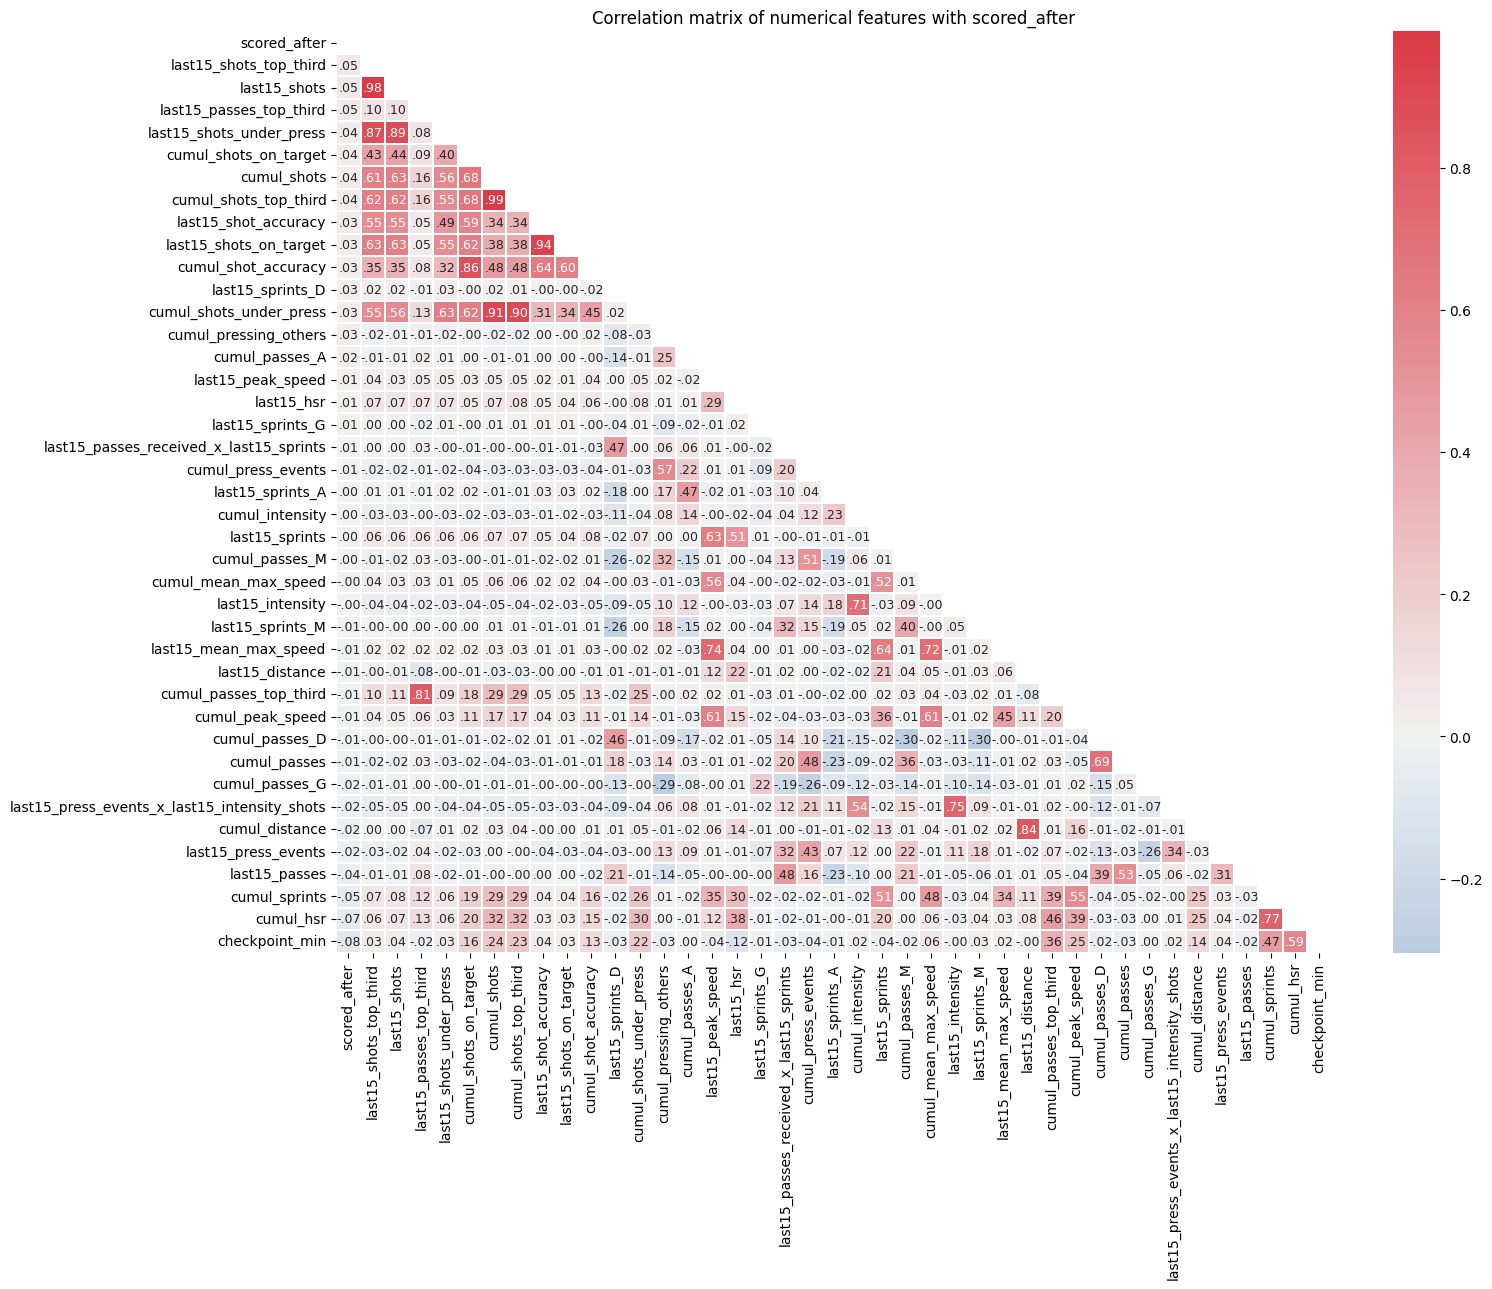

In [131]:
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlations, dtype=bool))

# Diverging colormap: blue for negative, red for positive
my_cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Custom annotations: .XX instead of 0.XX
annot_labels = correlations.applymap(lambda x: f"{x:.2f}".replace("0.", ".").replace("-0.", "-."))

plt.figure(figsize=(16, 13))
sns.heatmap(correlations,
            annot=annot_labels,
            fmt="",              # empty because we pass strings
            cmap=my_cmap,
            mask=mask,
            linewidths=0.3,
            center=0,
            annot_kws={"size": 9})   # smaller font to fit
plt.title('Correlation matrix of numerical features with scored_after')
plt.tight_layout()
plt.show()

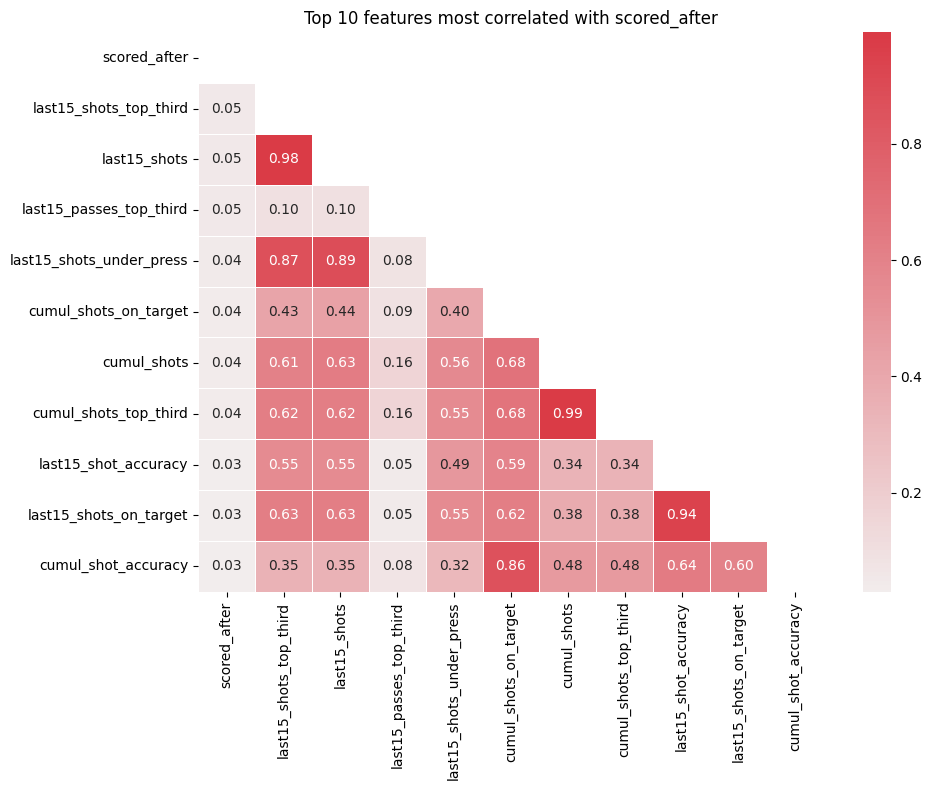

In [132]:
# Focus on top 10 features most correlated with scored_after
top_n = 11  # 10 features + scored_after itself

plt.figure(figsize=(10, 8))
sns.heatmap(correlations.iloc[:top_n, :top_n],
            annot=True,
            cmap=my_cmap,
            mask=mask[:top_n, :top_n],
            fmt=".2f",
            linewidths=0.5,
            center=0)
plt.title('Top 10 features most correlated with scored_after')
plt.tight_layout()
plt.show()